#1)Problem Statement:
The goal of this project is to detect fraudulent credit card transactions using machine learning.

The dataset contains information about credit card transactions with features such as Time, V1 to V28, Amount, and Class. The Class column is the target variable, where 0 represents normal transactions and 1 represents fraudulent transactions.

Since fraudulent transactions are very few compared to normal transactions, the dataset contains class imbalance. The objective of this project is to build a model that can correctly identify fraudulent transactions.

#2)Import Libraries:

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier

#3)Load Dataset:

In [2]:
dfcard=pd.read_csv("/content/creditcard.csv")

In [3]:
dfcard

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45641,42436,-2.481639,-2.439949,0.363642,1.216827,2.572442,-1.264220,-0.443652,0.075853,0.073188,...,-0.039426,0.480591,1.779358,-0.756700,-0.161099,0.685617,0.223071,0.139619,0.00,0.0
45642,42436,1.223475,0.014944,0.471312,-0.038410,-0.566793,-0.867970,-0.058213,-0.144080,0.164904,...,-0.053292,-0.093680,0.106348,0.471407,0.135555,0.968336,-0.065171,0.005184,7.49,0.0
45643,42436,1.258657,0.421016,0.325437,0.684259,-0.292529,-1.052786,0.145228,-0.253567,-0.100521,...,-0.278029,-0.757417,0.119613,0.369393,0.246145,0.091553,-0.017156,0.032557,0.89,0.0
45644,42437,-0.500147,1.000770,1.809639,-0.114551,0.333865,-0.577076,1.062325,-0.513050,-0.048285,...,-0.193814,-0.161410,0.036965,0.400154,-0.802486,-0.076097,-0.214317,-0.229160,2.69,0.0


In [4]:
dfcard.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
dfcard.shape

(45646, 31)

In [6]:
dfcard.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

#4)Handling Missing Values(NaNs):

In [7]:
dfcard.isna().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,1
V7,1
V8,1
V9,1


In [8]:
dfcard.isna().sum().sum()

np.int64(25)

In [9]:
dfcard = dfcard.dropna()

#5)Remove Errors/Data Cleaning :

<Axes: >

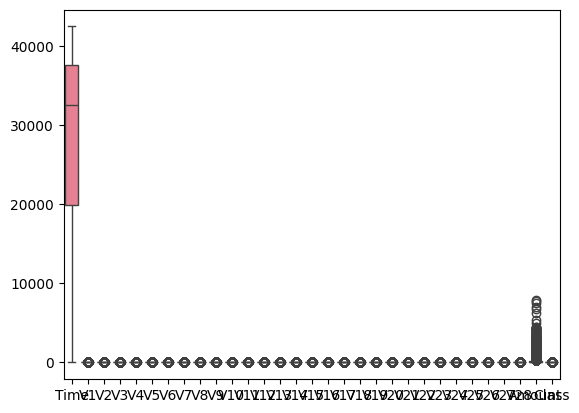

In [10]:
sns.boxplot(dfcard)

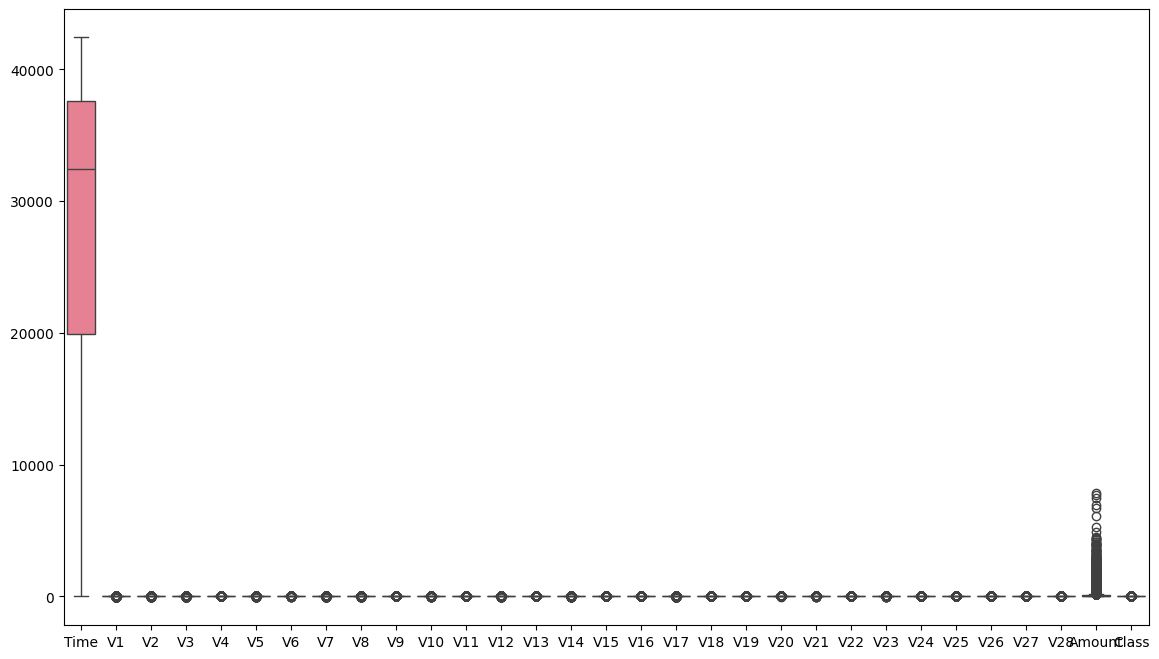

In [11]:
plt.figure(figsize=[14,8])
sns.boxplot(dfcard)
plt.show()

In [12]:
dfcard.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [13]:
dfcard["Class"]

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
45640,0.0
45641,0.0
45642,0.0
45643,0.0


In [14]:
dfcard["Class"].unique()

array([0., 1.])

In [15]:
dfcard["Class"].value_counts

<bound method IndexOpsMixin.value_counts of 0        0.0
1        0.0
2        0.0
3        0.0
4        0.0
        ... 
45640    0.0
45641    0.0
45642    0.0
45643    0.0
45644    0.0
Name: Class, Length: 45645, dtype: float64>

In [16]:
dfcard.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [17]:
cols=['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

In [18]:
cols

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount']

In [19]:
for c in cols:
  q1=dfcard[c].quantile(0.25)
  q3=dfcard[c].quantile(0.75)
  iqr=q3-q1
  lower=q1-(1.5*iqr)
  upper=q3+(1.5*iqr)
  dfcard[c]=dfcard[c].map(lambda x: lower if x<lower else upper if x>upper else x)


/tmp/ipykernel_346/1282043879.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfcard[c]=dfcard[c].map(lambda x: lower if x<lower else upper if x>upper else x)
/tmp/ipykernel_346/1282043879.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfcard[c]=dfcard[c].map(lambda x: lower if x<lower else upper if x>upper else x)
/tmp/ipykernel_346/1282043879.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

S

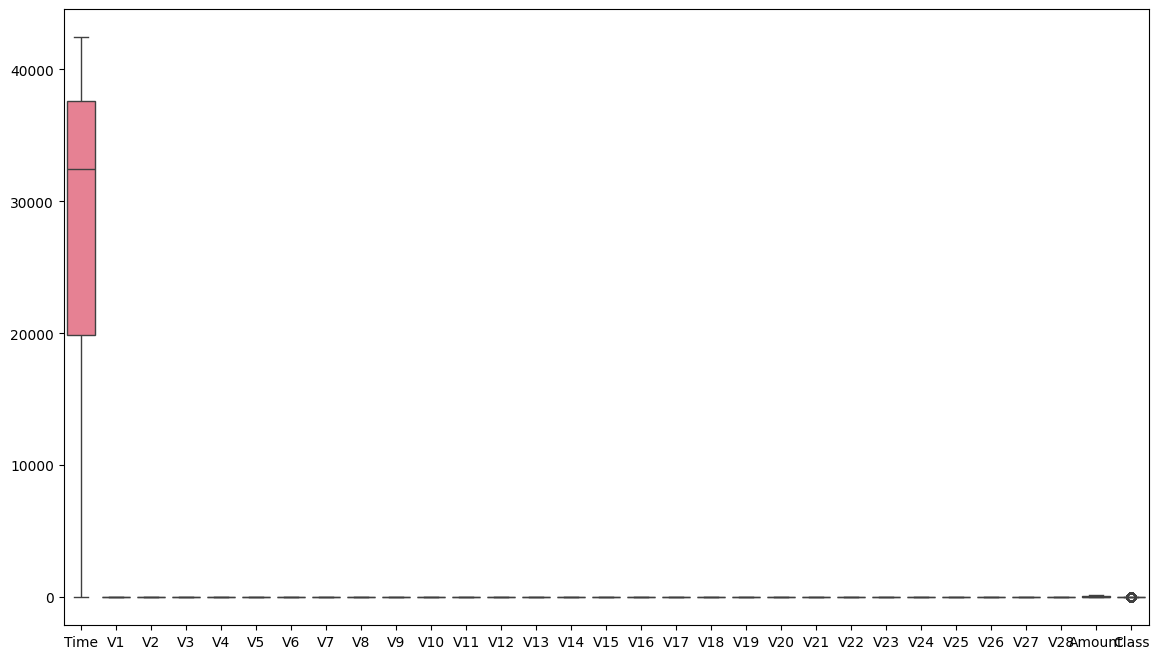

In [20]:
plt.figure(figsize=[14,8])
sns.boxplot(dfcard)
plt.show()

#6)Encoding Categorical Data:

In [21]:
dfcard.dtypes

,0
Time,int64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


#7)Data Seperation:

In [22]:
dfcard.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.463466,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,195.13,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.200778,69.99,0.0


In [23]:
dfcard.drop("Class",axis=1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.463466,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,195.13
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.200778,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45640,42436,1.330967,0.662949,-1.089077,0.425743,0.946620,-0.324689,0.366117,-0.157143,-0.528674,...,0.067418,-0.176830,-0.418278,-0.279397,-1.107096,0.765716,0.431469,-0.027864,0.021672,0.76
45641,42436,-2.481639,-2.439949,0.363642,1.216827,1.999209,-1.264220,-0.443652,0.075853,0.073188,...,-0.221691,-0.039426,0.480591,0.463466,-0.756700,-0.161099,0.685617,0.223071,0.139619,0.00
45642,42436,1.223475,0.014944,0.471312,-0.038410,-0.566793,-0.867970,-0.058213,-0.144080,0.164904,...,-0.076754,-0.053292,-0.093680,0.106348,0.471407,0.135555,0.968336,-0.065171,0.005184,7.49
45643,42436,1.258657,0.421016,0.325437,0.684259,-0.292529,-1.052786,0.145228,-0.253567,-0.100521,...,-0.026262,-0.278029,-0.757417,0.119613,0.369393,0.246145,0.091553,-0.017156,0.032557,0.89


In [24]:
X=dfcard.drop("Class",axis=1)

In [25]:
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.463466,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,195.13
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.200778,69.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45640,42436,1.330967,0.662949,-1.089077,0.425743,0.946620,-0.324689,0.366117,-0.157143,-0.528674,...,0.067418,-0.176830,-0.418278,-0.279397,-1.107096,0.765716,0.431469,-0.027864,0.021672,0.76
45641,42436,-2.481639,-2.439949,0.363642,1.216827,1.999209,-1.264220,-0.443652,0.075853,0.073188,...,-0.221691,-0.039426,0.480591,0.463466,-0.756700,-0.161099,0.685617,0.223071,0.139619,0.00
45642,42436,1.223475,0.014944,0.471312,-0.038410,-0.566793,-0.867970,-0.058213,-0.144080,0.164904,...,-0.076754,-0.053292,-0.093680,0.106348,0.471407,0.135555,0.968336,-0.065171,0.005184,7.49
45643,42436,1.258657,0.421016,0.325437,0.684259,-0.292529,-1.052786,0.145228,-0.253567,-0.100521,...,-0.026262,-0.278029,-0.757417,0.119613,0.369393,0.246145,0.091553,-0.017156,0.032557,0.89


In [26]:
y=dfcard["Class"]

In [27]:
y

,Class
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
45640,0.0
45641,0.0
45642,0.0
45643,0.0


#8)Imbalance:

In [28]:
y.value_counts()

,count
Class,
0.0,45503
1.0,142


<Axes: xlabel='Class'>

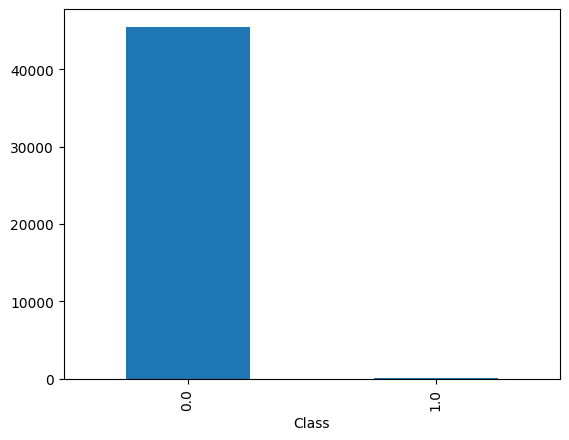

In [29]:
y.value_counts().plot(kind="bar")

In [30]:
from imblearn.over_sampling import SMOTE,RandomOverSampler

In [31]:
ros=RandomOverSampler()

In [32]:
ros

RandomOverSampler()

In [33]:
x_ros,y_ros=ros.fit_resample(X,y)

In [34]:
x_ros.shape

(91006, 30)

In [35]:
X.shape

(45645, 30)

In [36]:
y.value_counts()

,count
Class,
0.0,45503
1.0,142


In [37]:
y_ros.shape

(91006,)

In [38]:
y_ros.value_counts()

,count
Class,
0.0,45503
1.0,45503


<Axes: xlabel='Class'>

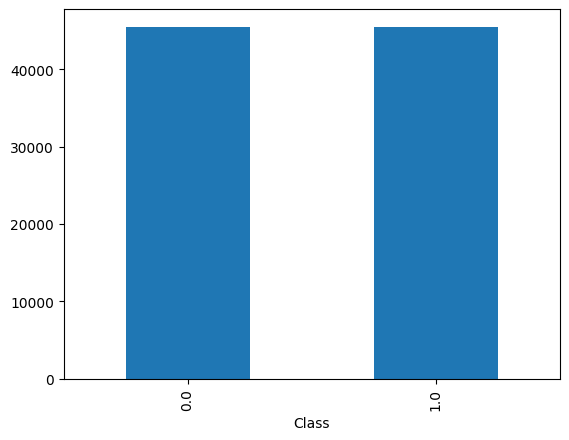

In [39]:
y_ros.value_counts().plot(kind="bar")

#9)Train Test Split:

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
x_train,x_test,y_train,y_test=train_test_split(x_ros,y_ros,test_size=0.30,random_state=20)

In [42]:
x_train.shape

(63704, 30)

In [43]:
x_test.shape

(27302, 30)

In [44]:
y_train.shape

(63704,)

In [45]:
y_test.shape

(27302,)

#10)Build and Train Model:

In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rfc_model=RandomForestClassifier()

In [48]:
rfc_model

RandomForestClassifier()

In [49]:
rfc_model.fit(x_train,y_train)

RandomForestClassifier()

In [50]:
rfc_model.score(x_test,y_test)

0.9999633726466925

#11)Cross Validation:

In [51]:
from sklearn.model_selection import cross_val_score,KFold,StratifiedKFold

In [52]:
score=cross_val_score(rfc_model,x_train,y_train,cv=3,n_jobs=2)

In [53]:
score.mean()

np.float64(0.9999058136522588)

KFold cross validation

In [54]:
kf=KFold(n_splits=3)

In [55]:
kfscore=cross_val_score(rfc_model,x_train,y_train,cv=kf,n_jobs=2)

In [56]:
kfscore.mean()

np.float64(0.9999058143915146)

StratifiedKFold cross validation

In [57]:
skf=StratifiedKFold(n_splits=3)

In [58]:
skfscore=cross_val_score(rfc_model,x_train,y_train,cv=skf,n_jobs=2)

In [59]:
skfscore.mean()

np.float64(0.9998744189422676)

#12)Hyperparameters:

In [60]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [61]:
rfc1=RandomForestClassifier( )

In [62]:
params = {
    "n_estimators": [50, 75, 100],
    "criterion": ["gini", "entropy"],
    "max_depth": [5, 6, 7, 8]
}


In [63]:
params

{'n_estimators': [50, 75, 100],
 'criterion': ['gini', 'entropy'],
 'max_depth': [5, 6, 7, 8]}

In [64]:
GridSearchCV(rfc1,params,cv=skf,n_jobs=-1)

GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8],
                         'n_estimators': [50, 75, 100]})

In [65]:
#gridcv=GridSearchCV(rfc1,params,cv=skf,n_jobs=2)

In [66]:
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [67]:
gridcv = GridSearchCV(
    estimator=rfc1,
    param_grid=params,
    cv=skf,
    n_jobs=2,
    verbose=2
)

In [68]:
gridcv.fit(x_ros,y_ros)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=StratifiedKFold(n_splits=3, random_state=None, shuffle=False),
             estimator=RandomForestClassifier(), n_jobs=2,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [5, 6, 7, 8],
                         'n_estimators': [50, 75, 100]},
             verbose=2)

In [69]:
gridcv.best_score_

np.float64(0.9973079239021502)

In [70]:
gridcv.best_params_

{'criterion': 'entropy', 'max_depth': 8, 'n_estimators': 50}

In [71]:
pd.DataFrame(gridcv.cv_results_)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_criterion,param_max_depth,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
0,8.389207,0.829683,0.093076,0.016864,gini,5,50,"{'criterion': 'gini', 'max_depth': 5, 'n_estim...",0.958169,0.995385,0.996407,0.983320,0.017790,22
1,12.122814,0.405311,0.159516,0.034678,gini,5,75,"{'criterion': 'gini', 'max_depth': 5, 'n_estim...",0.936412,0.995418,0.993011,0.974947,0.027266,24
2,17.286778,0.626504,0.166504,0.030827,gini,5,100,"{'criterion': 'gini', 'max_depth': 5, 'n_estim...",0.984935,0.991858,0.992978,0.989924,0.003557,17
3,8.260223,0.787780,0.082166,0.000564,gini,6,50,"{'criterion': 'gini', 'max_depth': 6, 'n_estim...",0.944027,0.999571,0.999868,0.981155,0.026254,23
4,13.283469,0.158270,0.122909,0.002906,gini,6,75,"{'criterion': 'gini', 'max_depth': 6, 'n_estim...",0.978573,0.995418,0.999868,0.991286,0.009171,13
5,17.549532,0.238766,0.187123,0.024578,gini,6,100,"{'criterion': 'gini', 'max_depth': 6, 'n_estim...",0.960245,0.999637,0.999868,0.986584,0.018624,21
6,9.132213,0.859818,0.128001,0.041125,gini,7,50,"{'criterion': 'gini', 'max_depth': 7, 'n_estim...",0.980353,0.999637,0.999868,0.993286,0.009145,7
7,13.430950,0.083297,0.154136,0.033047,gini,7,75,"{'criterion': 'gini', 'max_depth': 7, 'n_estim...",0.973497,0.999637,0.999868,0.991001,0.012378,14
8,18.030591,0.637429,0.167575,0.001831,gini,7,100,"{'criterion': 'gini', 'max_depth': 7, 'n_estim...",0.961102,0.999637,0.999868,0.986869,0.018220,20
9,9.340331,0.811279,0.099279,0.006145,gini,8,50,"{'criterion': 'gini', 'max_depth': 8, 'n_estim...",0.985562,0.999670,0.999868,0.995033,0.006698,4


#12)Conclusion:
In this project, a Random Forest Classifier model was used to detect fraudulent credit card transactions. Hyperparameter tuning was applied to improve the model performance.

The model achieved an accuracy score of about 99%, which shows that the model can effectively detect fraudulent transactions.